1. IMPORT AND DRIVE MOUNT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, random, copy, math, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py

Mounted at /content/drive


2. CONFIGURATION

In [2]:
NUM_CHUNKS   = 3
EPOCHS_CHUNK = 20

EXP1_BEST = "/content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/best_unimatch.pth"

CFG = {
    "DATA_ROOT"  : "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data",
    "SAVE_DIR"   : "/content/drive/MyDrive/MRI_Project/Incremental_UniMatch_Exp2/",
    "BACKUP_DIR" : "/content/drive/MyDrive/MRI_Project/Incremental_Backups_Exp2/",

    "LABELED_RATIO" : 0.20,
    "SKIP_EMPTY"    : 0.80,

    "IN_CHANNELS"   : 4,
    "NUM_CLASSES"   : 3,
    "BASE_CHANNELS" : 32,
    "DROPOUT"       : 0.10,

    "EPOCHS"        : EPOCHS_CHUNK,
    "BATCH_SIZE"    : 4,

    "LR"            : 3e-5,
    "WEIGHT_DECAY"  : 1e-4,
    "NUM_WORKERS"   : 2,
    "SEED"          : 42,

    "CONF_THR"      : 0.40,
    "LAMBDA_U"      : 0.15,
    "EMA_ALPHA"     : 0.99,

    "SAVE_EVERY"    : 2,
    "VAL_EVERY"     : 2,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
os.makedirs(CFG["SAVE_DIR"],   exist_ok=True)
os.makedirs(CFG["BACKUP_DIR"], exist_ok=True)

Device : cuda


3. SEEDING

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CFG["SEED"])

4. DATA UTILITIES

In [4]:
def load_h5(path):
    with h5py.File(path, 'r') as f:
        image = f['image'][:].astype(np.float32)
        mask  = f['mask'][:].astype(np.float32)
    image = np.transpose(image, (2, 0, 1))
    mask  = np.transpose(mask,  (2, 0, 1))
    return image, mask

def normalize_image(image):
    out = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[0]):
        ch = image[c]
        m  = ch > 0
        if m.sum() == 0:
            out[c] = ch
            continue
        mu, sigma = ch[m].mean(), ch[m].std() + 1e-8
        out[c] = (ch - mu) / sigma
    return out

def split_patients(root, labeled_ratio=0.20, seed=42):
    all_files = sorted([f for f in os.listdir(root) if f.endswith(".h5")])
    if len(all_files) == 0:
        raise ValueError(f"No .h5 files found in {root}")
    volumes = sorted(set([f.split("_slice_")[0] for f in all_files]))
    rng = random.Random(seed)
    rng.shuffle(volumes)
    val_n     = max(1, int(len(volumes) * 0.15))
    val       = volumes[:val_n]
    train     = volumes[val_n:]
    lab_n     = max(1, int(len(train) * labeled_ratio))
    labeled   = train[:lab_n]
    unlabeled = train[lab_n:]
    print(f"Volumes  total={len(volumes)}  labeled={len(labeled)}"
          f"  unlabeled={len(unlabeled)}  val={len(val)}")
    def get_files(vol_list):
        vol_set = set(vol_list)
        return [os.path.join(root, f) for f in all_files
                if f.split("_slice_")[0] in vol_set]
    return get_files(labeled), get_files(unlabeled), get_files(val)

def inf_loader(dl):
    while True:
        for b in dl: yield b

def permanent_save(src_dir, backup_dir):
    os.makedirs(backup_dir, exist_ok=True)
    count = 0
    for f in os.listdir(src_dir):
        if f.endswith(".pth"):
            shutil.copy2(os.path.join(src_dir, f),
                         os.path.join(backup_dir, f))
            count += 1
    print(f"  [BACKUP] {count} files → {backup_dir}")

5. AUGMENTATION

In [5]:
def weak_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy(); lbl = lbl[:, ::-1].copy()
    return img, lbl

def strong_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy(); lbl = lbl[:, ::-1].copy()
    if random.random() > 0.5:
        img = img[:, :, ::-1].copy(); lbl = lbl[:, :, ::-1].copy()
    k = random.randint(0, 3)
    if k:
        img = np.rot90(img, k, (1, 2)).copy()
        lbl = np.rot90(lbl, k, (1, 2)).copy()
    if random.random() > 0.5:
        img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
    for c in range(img.shape[0]):
        if random.random() > 0.5:
            img[c] = img[c] * random.uniform(0.8, 1.2)
    return img, lbl

def cutmix(img1, lbl1, img2, lbl2, alpha=1.0):
    _, H, W = img1.shape
    lam = np.random.beta(alpha, alpha)
    cw = int(W * math.sqrt(1-lam)); ch = int(H * math.sqrt(1-lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, y1 = max(cx-cw//2, 0), max(cy-ch//2, 0)
    x2, y2 = min(cx+cw//2, W), min(cy+ch//2, H)
    out_img = img1.copy(); out_lbl = lbl1.copy()
    out_img[:, y1:y2, x1:x2] = img2[:, y1:y2, x1:x2]
    out_lbl[:, y1:y2, x1:x2] = lbl2[:, y1:y2, x1:x2]
    return out_img, out_lbl

    img = img[:, ::-1].copy()
    lbl = lbl[:, ::-1].copy()
    if random.random() > 0.5:
        img = img[:, :, ::-1].copy()
        lbl = lbl[:, :, ::-1].copy()
    k = random.randint(0, 3)
    if k:
        img = np.rot90(img, k, (1, 2)).copy()
        lbl = np.rot90(lbl, k, (1, 2)).copy()
    if random.random() > 0.5:
        img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
    for c in range(img.shape[0]):
        if random.random() > 0.5:
            img[c] = img[c] * random.uniform(0.8, 1.2)
    return img, lbl

def cutmix(img1, lbl1, img2, lbl2, alpha=1.0):
    _, H, W = img1.shape
    lam = np.random.beta(alpha, alpha)
    cw  = int(W * math.sqrt(1 - lam))
    ch  = int(H * math.sqrt(1 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, y1 = max(cx - cw//2, 0), max(cy - ch//2, 0)
    x2, y2 = min(cx + cw//2, W), min(cy + ch//2, H)
    out_img = img1.copy()
    out_lbl = lbl1.copy()
    out_img[:, y1:y2, x1:x2] = img2[:, y1:y2, x1:x2]
    out_lbl[:, y1:y2, x1:x2] = lbl2[:, y1:y2, x1:x2]
    return out_img, out_lbl

6. DATASETS

In [6]:
class LabeledDS(Dataset):
    def __init__(self, file_paths, skip_empty=0.8):
        self.files = []
        for fp in file_paths:
            _, mask = load_h5(fp)
            if mask.sum() == 0 and random.random() < skip_empty:
                continue
            self.files.append(fp)

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        image, mask = weak_aug(image, mask)
        return {"image": torch.from_numpy(image.copy()),
                "label": torch.from_numpy(mask.copy())}

class UnlabeledDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        dummy = np.zeros_like(mask)
        iw,  _ = weak_aug(image.copy(),  dummy.copy())
        is1, _ = strong_aug(image.copy(), dummy.copy())
        is2, _ = strong_aug(image.copy(), dummy.copy())
        is1, _ = cutmix(is1, dummy, is2, dummy)
        return {"image_weak":    torch.from_numpy(iw.copy()),
                "image_strong1": torch.from_numpy(is1.copy()),
                "image_strong2": torch.from_numpy(is2.copy())}

class ValDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        return {"image": torch.from_numpy(image.copy()),
                "label": torch.from_numpy(mask.copy())}


7. U-NET MODEL

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True), nn.Dropout2d(drop),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True))
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(ic, oc, drop))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.up   = nn.ConvTranspose2d(ic, ic//2, 2, stride=2)
        self.conv = DoubleConv(ic, oc)
    def forward(self, x, skip):
        x  = self.up(x)
        dh = skip.size(2)-x.size(2); dw = skip.size(3)-x.size(3)
        x  = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        return self.conv(torch.cat([skip, x], 1))

class UNet2D(nn.Module):
    def __init__(self, ic=4, nc=3, b=32, drop=0.1):
        super().__init__()
        self.inc=DoubleConv(ic,b); self.d1=Down(b,b*2)
        self.d2=Down(b*2,b*4);    self.d3=Down(b*4,b*8)
        self.d4=Down(b*8,b*16,drop)
        self.u1=Up(b*16,b*8); self.u2=Up(b*8,b*4)
        self.u3=Up(b*4,b*2);  self.u4=Up(b*2,b)
        self.outc=nn.Conv2d(b,nc,1)

    def forward(self, x):
        x1=self.inc(x); x2=self.d1(x1); x3=self.d2(x2)
        x4=self.d3(x3); x5=self.d4(x4)
        d=self.u1(x5,x4); d=self.u2(d,x3)
        d=self.u3(d,x2);  feat=self.u4(d,x1)
        return self.outc(feat), feat

8. LOSS FUNCTIONS

In [8]:
def sup_loss(logits, labels):
    weights = torch.tensor([2.0, 3.0, 1.0]).to(logits.device)
    bce   = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=weights.view(1,3,1,1))
    sig   = torch.sigmoid(logits)
    inter = (sig*labels).sum((2,3))
    union = sig.sum((2,3)) + labels.sum((2,3))
    dice  = (1-(2*inter+1e-5)/(union+1e-5)).mean()
    return 0.5*bce + 0.5*dice

def consist_loss(pred, pseudo, mask):
    loss = F.binary_cross_entropy_with_logits(pred, pseudo, reduction='none')
    return (loss*mask.unsqueeze(1)).sum() / (mask.sum()+1e-8)

def ema_update(teacher, student, alpha=0.999):
    for tp, sp in zip(teacher.parameters(), student.parameters()):
        tp.data.mul_(alpha).add_(sp.data, alpha=1-alpha)

9. METRICS AND VALIDATION

In [9]:
def dice_coef(p, g, smooth=1e-5):
    return float((2*(p&g).sum()+smooth)/(p.sum()+g.sum()+smooth))

def brats_metrics(pred, gt):
    names = ("WT","TC","ET"); res = {}
    for i, n in enumerate(names):
        p = pred[i]>0.5; g = gt[i]>0.5
        res[f"Dice_{n}"] = dice_coef(p, g)
    res["Dice_mean"] = float(np.nanmean([res[f"Dice_{n}"] for n in names]))
    return res

@torch.no_grad()
def validate(teacher, val_loader, device):
    teacher.eval()
    all_m = []
    for batch in val_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].numpy()
        preds  = torch.sigmoid(teacher(imgs)[0]).cpu().numpy()
        for p, g in zip(preds, labels):
            all_m.append(brats_metrics(p, g))
    keys = all_m[0].keys()
    return {k: float(np.nanmean([m[k] for m in all_m])) for k in keys}

10. CHECKPOINT HELPER

In [10]:
def save_checkpoint(path, epoch, student, teacher,
                    optimizer, scheduler, best_dice, metrics_history):
    torch.save({
        "epoch": epoch, "student_state": student.state_dict(),
        "teacher_state": teacher.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_dice": best_dice, "metrics_history": metrics_history,
        "cfg": CFG,
    }, path)
    print(f"  [CKPT] Saved → {path}")

def load_checkpoint(path, student, teacher, optimizer, scheduler):
    ckpt = torch.load(path, map_location=DEVICE)
    student.load_state_dict(ckpt["student_state"])
    teacher.load_state_dict(ckpt["teacher_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"  [CKPT] Resumed epoch={ckpt['epoch']} best={ckpt['best_dice']:.4f}")
    return ckpt["epoch"], ckpt["best_dice"], ckpt.get("metrics_history", [])

def load_weights_only(path, student, teacher):
    # ✅ Only loads model weights — NOT optimizer/scheduler
    ckpt = torch.load(path, map_location=DEVICE)
    student.load_state_dict(ckpt["student_state"])
    teacher.load_state_dict(ckpt["teacher_state"])
    print(f"  [WEIGHTS] Loaded from {path} (dice={ckpt['best_dice']:.4f})")
    return ckpt["best_dice"]

11. DATA SPLITS AND CHUNKS

In [13]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
all_labeled, all_unlabeled, val_files = split_patients(
    CFG["DATA_ROOT"], CFG["LABELED_RATIO"], CFG["SEED"])

print(f"\nFull dataset — Labeled:{len(all_labeled)} "
      f"Unlabeled:{len(all_unlabeled)} Val:{len(val_files)}")

rng = random.Random(CFG["SEED"] + 1)
rng.shuffle(all_labeled)
rng.shuffle(all_unlabeled)

lab_chunk_size   = len(all_labeled)   // NUM_CHUNKS
unlab_chunk_size = len(all_unlabeled) // NUM_CHUNKS

labeled_chunks   = []
unlabeled_chunks = []

for i in range(NUM_CHUNKS):
    l_start = i * lab_chunk_size
    l_end   = len(all_labeled) if i==NUM_CHUNKS-1 else (i+1)*lab_chunk_size
    u_start = i * unlab_chunk_size
    u_end   = len(all_unlabeled) if i==NUM_CHUNKS-1 else (i+1)*unlab_chunk_size
    labeled_chunks.append(all_labeled[l_start:l_end])
    unlabeled_chunks.append(all_unlabeled[u_start:u_end])
    print(f"Chunk {i+1}: {len(labeled_chunks[i])} labeled | "
          f"{len(unlabeled_chunks[i])} unlabeled")

val_ds     = ValDS(val_files)
val_loader = DataLoader(val_ds, batch_size=CFG["BATCH_SIZE"],
                        shuffle=False, num_workers=CFG["NUM_WORKERS"],
                        pin_memory=True)
print(f"Val DS: {len(val_ds)} slices")

Volumes  total=263  labeled=44  unlabeled=180  val=39

Full dataset — Labeled:6820 Unlabeled:27900 Val:5904
Chunk 1: 2273 labeled | 9300 unlabeled
Chunk 2: 2273 labeled | 9300 unlabeled
Chunk 3: 2274 labeled | 9300 unlabeled
Val DS: 5904 slices


12. INTIALIZE MODEL AND LOAD EXP-1 WEIGHTS

In [15]:
student = UNet2D(CFG["IN_CHANNELS"], CFG["NUM_CLASSES"],
                 CFG["BASE_CHANNELS"], CFG["DROPOUT"]).to(DEVICE)
teacher = copy.deepcopy(student)
for p in teacher.parameters(): p.requires_grad_(False)

total_epochs = CFG["EPOCHS"] * NUM_CHUNKS
optimizer = optim.AdamW(student.parameters(),
                        lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_epochs, eta_min=CFG["LR"]*0.01)

if os.path.exists(EXP1_BEST):
    exp1_dice = load_weights_only(EXP1_BEST, student, teacher)
    print(f"Starting from Exp1 pretrained weights (Dice={exp1_dice:.4f})")
else:
    print(f"WARNING: Exp1 checkpoint not found at {EXP1_BEST}")
    print("Starting from random weights")

print(f"Model params   : {sum(p.numel() for p in student.parameters()):,}")
print(f"Total epochs   : {total_epochs} ({NUM_CHUNKS} chunks x {CFG['EPOCHS']})")

  [WEIGHTS] Loaded from /content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/best_unimatch.pth (dice=0.8414)
Starting from Exp1 pretrained weights (Dice=0.8414)
Model params   : 7,763,395
Total epochs   : 60 (3 chunks x 20)


TRAINING LOOP

In [16]:
for chunk_id in range(NUM_CHUNKS):

    print(f"\n{'='*70}")
    print(f"  CHUNK {chunk_id+1}/{NUM_CHUNKS} | "
          f"Labeled={len(labeled_chunks[chunk_id])} | "
          f"Unlabeled={len(unlabeled_chunks[chunk_id])}")
    print(f"{'='*70}")

    labeled_ds   = LabeledDS(labeled_chunks[chunk_id], CFG["SKIP_EMPTY"])
    unlabeled_ds = UnlabeledDS(unlabeled_chunks[chunk_id])

    labeled_loader   = DataLoader(labeled_ds, CFG["BATCH_SIZE"], shuffle=True,
                                   num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                                   drop_last=True)
    unlabeled_loader = DataLoader(unlabeled_ds, CFG["BATCH_SIZE"], shuffle=True,
                                   num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                                   drop_last=True)

    print(f"Labeled DS after skip_empty : {len(labeled_ds)}")
    print(f"Iters/epoch : {len(labeled_loader)}")

    # Resume logic
    start_epoch     = 0
    best_dice       = 0.0
    metrics_history = []

    CHUNK_LATEST = os.path.join(CFG["SAVE_DIR"],   f"chunk{chunk_id+1}_latest.pth")
    CHUNK_BACKUP = os.path.join(CFG["BACKUP_DIR"], f"chunk{chunk_id+1}_latest.pth")
    PREV_BEST    = os.path.join(CFG["SAVE_DIR"],   f"chunk{chunk_id}_best.pth")
    PREV_BACKUP  = os.path.join(CFG["BACKUP_DIR"], f"chunk{chunk_id}_best.pth")

    if os.path.exists(CHUNK_LATEST):
        print(f"Resuming chunk {chunk_id+1} from latest...")
        start_epoch, best_dice, metrics_history = load_checkpoint(
            CHUNK_LATEST, student, teacher, optimizer, scheduler)
    elif os.path.exists(CHUNK_BACKUP):
        print(f"Resuming chunk {chunk_id+1} from backup...")
        start_epoch, best_dice, metrics_history = load_checkpoint(
            CHUNK_BACKUP, student, teacher, optimizer, scheduler)
    elif chunk_id > 0:
        # ✅ Carry weights from previous chunk only
        if os.path.exists(PREV_BEST):
            load_weights_only(PREV_BEST, student, teacher)
        elif os.path.exists(PREV_BACKUP):
            load_weights_only(PREV_BACKUP, student, teacher)
        else:
            print(f"WARNING: No chunk {chunk_id} checkpoint found")
    else:
        print(f"Starting chunk 1 with Exp1 pretrained weights")

    # Skip if already complete
    if start_epoch >= CFG["EPOCHS"]:
        print(f"Chunk {chunk_id+1} already complete — skipping")
        continue

    # Training loop
    unl_iter = inf_loader(unlabeled_loader)
    iters    = len(labeled_loader)
    train_start = time.time()

    for epoch in range(start_epoch + 1, CFG["EPOCHS"] + 1):
        student.train(); teacher.train()
        ep_sup = ep_u = ep_tot = ep_conf = 0.0
        ep_start = time.time()

        for lbatch in labeled_loader:
            ubatch = next(unl_iter)
            imgs   = lbatch["image"].to(DEVICE)
            labels = lbatch["label"].to(DEVICE)
            iw     = ubatch["image_weak"].to(DEVICE)
            is1    = ubatch["image_strong1"].to(DEVICE)
            is2    = ubatch["image_strong2"].to(DEVICE)

            logits, _ = student(imgs)
            l_sup = sup_loss(logits, labels)

            with torch.no_grad():
                lw, _  = teacher(iw)
                probs  = torch.sigmoid(lw)
                conf   = probs.max(1).values
                pseudo = (probs > 0.5).float()
                mask   = (conf >= CFG["CONF_THR"]).float()

            ls1, _ = student(is1)
            ls2, _ = student(is2)
            l_u = 0.5*(consist_loss(ls1, pseudo, mask) +
                       consist_loss(ls2, pseudo, mask))

            loss = l_sup + CFG["LAMBDA_U"] * l_u

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()
            ema_update(teacher, student, CFG["EMA_ALPHA"])

            ep_sup  += l_sup.item()
            ep_u    += l_u.item()
            ep_tot  += loss.item()
            ep_conf += mask.mean().item()

        scheduler.step()

        ep_dur  = time.time() - ep_start
        eta_sec = (CFG["EPOCHS"] - epoch) * ep_dur
        h, m    = divmod(int(eta_sec), 3600); m //= 60

        print(f"[C{chunk_id+1}] Ep {epoch:3d}/{CFG['EPOCHS']} | "
              f"L_sup={ep_sup/iters:.4f}  L_u={ep_u/iters:.4f}  "
              f"L_tot={ep_tot/iters:.4f}  conf%={ep_conf/iters*100:.1f}  "
              f"[{ep_dur:.0f}s/ep  ETA {h}h{m:02d}m]")

        if epoch % CFG["VAL_EVERY"] == 0 or epoch == CFG["EPOCHS"]:
            m = validate(teacher, val_loader, DEVICE)
            metrics_history.append({"epoch": epoch, "chunk": chunk_id+1, **m})
            print(f"  >> VAL  WT={m['Dice_WT']:.4f}  TC={m['Dice_TC']:.4f}  "
                  f"ET={m['Dice_ET']:.4f}  Mean={m['Dice_mean']:.4f}")

            if m["Dice_mean"] > best_dice:
                best_dice = m["Dice_mean"]
                save_checkpoint(
                    os.path.join(CFG["SAVE_DIR"], f"chunk{chunk_id+1}_best.pth"),
                    epoch, student, teacher, optimizer, scheduler,
                    best_dice, metrics_history)
                permanent_save(CFG["SAVE_DIR"], CFG["BACKUP_DIR"])

        if epoch % CFG["SAVE_EVERY"] == 0:
            save_checkpoint(
                os.path.join(CFG["SAVE_DIR"], f"chunk{chunk_id+1}_latest.pth"),
                epoch, student, teacher, optimizer, scheduler,
                best_dice, metrics_history)
            permanent_save(CFG["SAVE_DIR"], CFG["BACKUP_DIR"])

    total_time = time.time() - train_start
    th, tm = divmod(int(total_time), 3600); tm //= 60
    print(f"\n  Chunk {chunk_id+1} complete | {th}h {tm}m | Best Dice={best_dice:.4f}")

print(f"\n{'='*70}")
print(f"  ALL CHUNKS COMPLETE")
print(f"{'='*70}")


  CHUNK 1/3 | Labeled=2273 | Unlabeled=9300
Labeled DS after skip_empty : 1234
Iters/epoch : 308
Resuming chunk 1 from latest...
  [CKPT] Resumed epoch=20 best=0.7972
Chunk 1 already complete — skipping

  CHUNK 2/3 | Labeled=2273 | Unlabeled=9300
Labeled DS after skip_empty : 1198
Iters/epoch : 299
Resuming chunk 2 from latest...
  [CKPT] Resumed epoch=20 best=0.8052
Chunk 2 already complete — skipping

  CHUNK 3/3 | Labeled=2274 | Unlabeled=9300
Labeled DS after skip_empty : 1217
Iters/epoch : 304
Resuming chunk 3 from latest...
  [CKPT] Resumed epoch=18 best=0.8142
[C3] Ep  19/20 | L_sup=0.3118  L_u=1.3085  L_tot=0.5080  conf%=2.4  [248s/ep  ETA 0h04m]
[C3] Ep  20/20 | L_sup=0.3116  L_u=1.3770  L_tot=0.5181  conf%=2.4  [243s/ep  ETA 0h00m]
  >> VAL  WT=0.7341  TC=0.5862  ET=0.7854  Mean=0.7019
  [CKPT] Saved → /content/drive/MyDrive/MRI_Project/Incremental_UniMatch_Exp2/chunk3_latest.pth
  [BACKUP] 6 files → /content/drive/MyDrive/MRI_Project/Incremental_Backups_Exp2/

  Chunk 3 co

FINAL EVALUATION

In [17]:
best_overall      = None
best_overall_dice = 0.0

for c in range(NUM_CHUNKS):
    for folder in [CFG["SAVE_DIR"], CFG["BACKUP_DIR"]]:
        path = os.path.join(folder, f"chunk{c+1}_best.pth")
        if os.path.exists(path):
            ckpt = torch.load(path, map_location=DEVICE)
            if ckpt["best_dice"] > best_overall_dice:
                best_overall_dice = ckpt["best_dice"]
                best_overall = path

print(f"Best checkpoint: {best_overall} (Dice={best_overall_dice:.4f})")
ckpt = torch.load(best_overall, map_location=DEVICE)
teacher.load_state_dict(ckpt["teacher_state"])

final = validate(teacher, val_loader, DEVICE)
print("\n=== Final Evaluation ===")
for k, v in final.items():
    print(f"  {k:12s} : {v:.4f}")

Best checkpoint: /content/drive/MyDrive/MRI_Project/Incremental_UniMatch_Exp2/chunk3_best.pth (Dice=0.8142)

=== Final Evaluation ===
  Dice_WT      : 0.8303
  Dice_TC      : 0.7271
  Dice_ET      : 0.8853
  Dice_mean    : 0.8142


SAMPLE SELCTION CELL AND VISUALIZATION

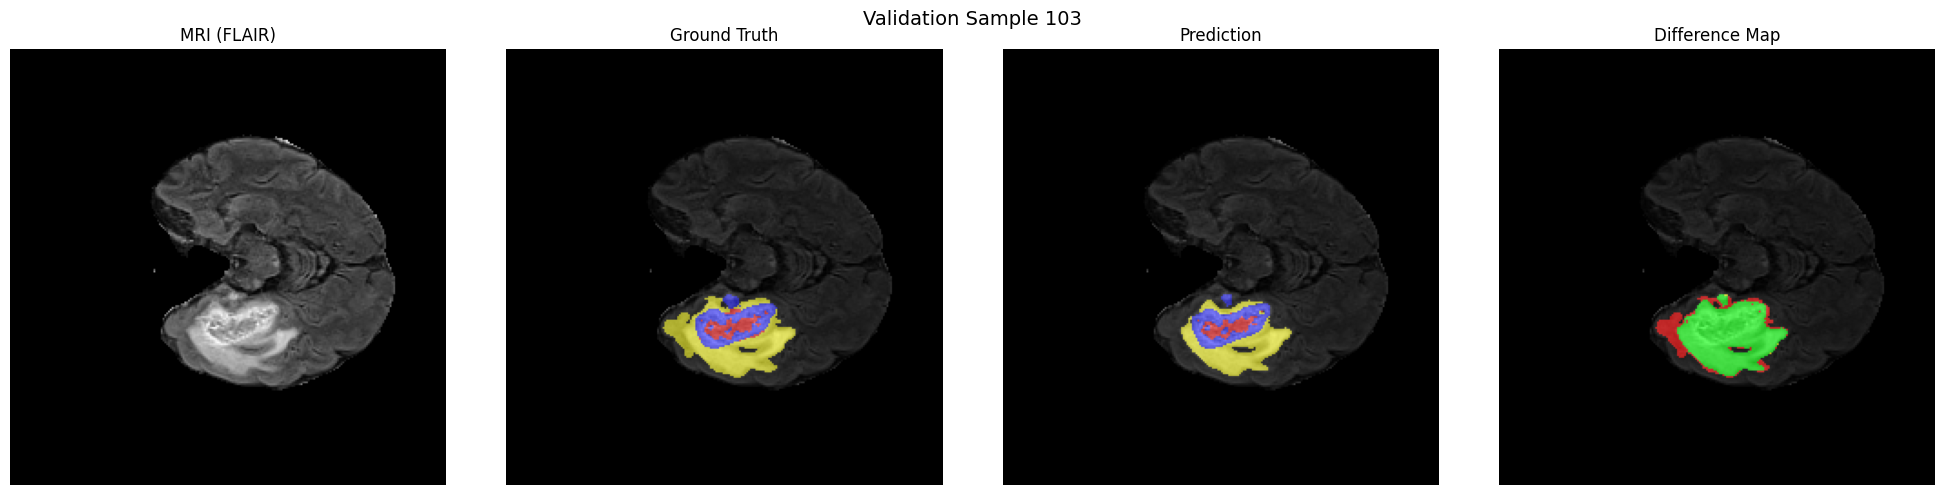

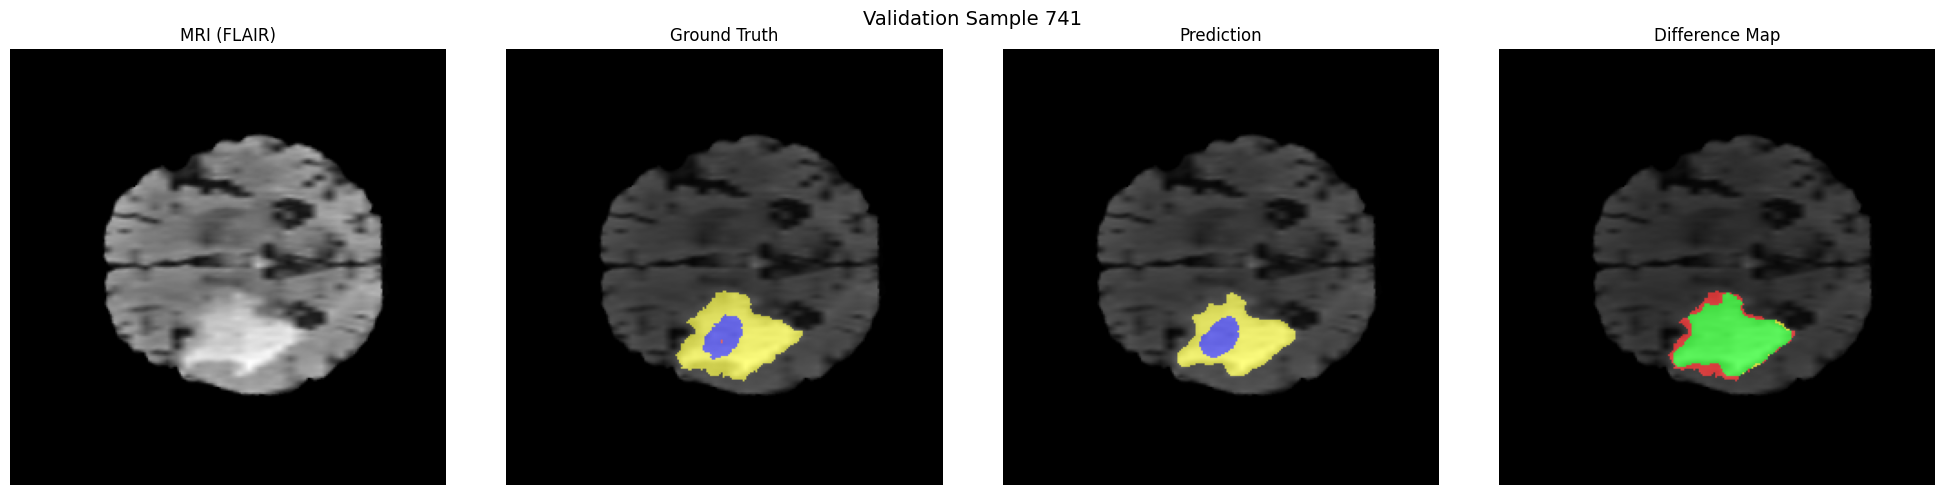

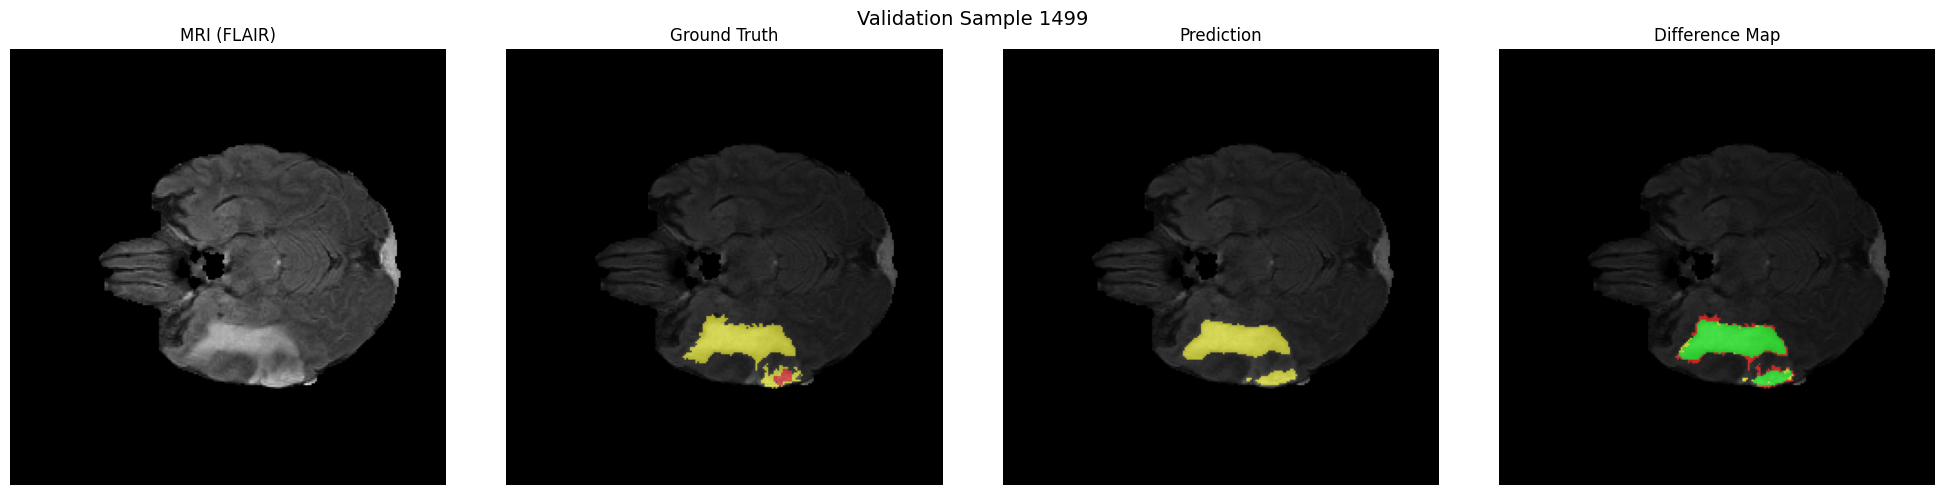

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

samples_to_show = [103, 741, 1499]   # or any slices you want

for idx in samples_to_show:

    sample = val_ds[idx]

    img = sample["image"].unsqueeze(0).to(DEVICE)
    flair = sample["image"][0].numpy()

    gt = sample["label"].numpy()

    with torch.no_grad():
        pred = torch.sigmoid(
            teacher(img)[0]
        ).cpu().numpy()[0]

    pred_bin = (pred > 0.5).astype(np.uint8)

    # =========================
    # Ground Truth Overlay
    # =========================

    gt_overlay = np.zeros((*gt[0].shape, 3))

    gt_overlay[gt[0] == 1] = [1, 0, 0]      # WT = Red
    gt_overlay[gt[1] == 1] = [1, 1, 0]      # TC = Yellow
    gt_overlay[gt[2] == 1] = [0, 0, 1]      # ET = Blue

    # =========================
    # Prediction Overlay
    # =========================

    pred_overlay = np.zeros((*gt[0].shape, 3))

    pred_overlay[pred_bin[0] == 1] = [1, 0, 0]
    pred_overlay[pred_bin[1] == 1] = [1, 1, 0]
    pred_overlay[pred_bin[2] == 1] = [0, 0, 1]

    # =========================
    # Difference Map
    # =========================

    diff = np.zeros((*gt[0].shape, 3))

    gt_union = (gt.sum(0) > 0)
    pred_union = (pred_bin.sum(0) > 0)

    diff[np.logical_and(gt_union, pred_union)] = [0, 1, 0]   # Green = Correct
    diff[np.logical_and(gt_union, ~pred_union)] = [1, 0, 0]  # Red = Missed
    diff[np.logical_and(~gt_union, pred_union)] = [1, 1, 0]  # Yellow = Extra

    # =========================
    # Plot
    # =========================

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # MRI
    axes[0].imshow(flair, cmap="gray")
    axes[0].set_title("MRI (FLAIR)")
    axes[0].axis("off")

    # GT
    axes[1].imshow(flair, cmap="gray")
    axes[1].imshow(gt_overlay, alpha=0.5)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(flair, cmap="gray")
    axes[2].imshow(pred_overlay, alpha=0.5)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    # Difference
    axes[3].imshow(flair, cmap="gray")
    axes[3].imshow(diff, alpha=0.6)
    axes[3].set_title("Difference Map")
    axes[3].axis("off")

    plt.suptitle(f"Validation Sample {idx}", fontsize=14)

    plt.tight_layout()
    plt.show()